# Suturing Quality Scoring - Overall Hybrid Aggregation (Ticket 04)

ADR-0001: the final `Overall` is a learned function of the five predicted
parameters **plus a residual channel that reads the image directly** (the
ordinal model's Overall-head expected score). Both variants are compared by
out-of-fold MAE; the residual is kept only if it genuinely helps. This
notebook runs the decision on the held-out slice of the Train cohort, using
the trained checkpoint from ticket 03.

In [1]:
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
%matplotlib inline

from suture_scoring.aggregate import LinearAggregation, evaluate_residual
from suture_scoring.data import SCORE_KEYS, load_annotations
from suture_scoring.dataset import SutureDataset, split_annotations
from suture_scoring.ordinal import ordinal_expected
from suture_scoring.train import load_model

PARAM_KEYS = [k for k in SCORE_KEYS if k != "Overall"]
TRAIN_XLSX = ROOT / "Dataset/Train/Train_cohort/Train_annotations.xlsx"
TRAIN_IMAGES = ROOT / "Dataset/Train/Train_cohort/Train"
CHECKPOINT = ROOT / "models/tiny-cpu.pt"

In [2]:
annotations = load_annotations(TRAIN_XLSX)
train_anns, val_anns = split_annotations(annotations, frac=0.12, seed=0)
print(f"{len(train_anns)} train / {len(val_anns)} held-out images")

889 train / 121 held-out images


In [3]:
model = load_model(CHECKPOINT).eval()
device = next(model.parameters()).device
ds = SutureDataset(TRAIN_IMAGES, val_anns, size=224, augment=False)

rows = []
with torch.no_grad():
    for image, targets in ds:
        logits = model(image.unsqueeze(0).to(device))
        row = {"name": None}
        for key in SCORE_KEYS:
            row[key] = int(targets[key].item())
        for key in PARAM_KEYS:
            row[f"pred_{key}"] = int(logits[key][0].argmax().item())
        row["pred_expected_Overall"] = float(ordinal_expected(logits["Overall"][0]).item())
        rows.append(row)

df = pd.DataFrame(rows)
df.head()

,name,Overall,ISD,Slack,Position,Angulation,Width,pred_ISD,pred_Slack,pred_Position,pred_Angulation,pred_Width,pred_expected_Overall
0,None,6,7,6,5,6,8,3,0,0,1,3,5.237571
1,None,6,5,8,7,5,7,3,0,0,1,3,5.250020
2,None,3,5,5,3,5,6,3,0,0,1,3,5.276013
3,None,8,8,8,6,8,7,3,0,0,1,3,5.239226
4,None,4,8,4,3,7,8,3,0,0,1,3,5.286989


In [4]:
X = df[[f"pred_{k}" for k in PARAM_KEYS]].to_numpy(dtype=float)
y = df["Overall"].to_numpy(dtype=float)
residual = df["pred_expected_Overall"].to_numpy(dtype=float)

decision = evaluate_residual(X, y, residual, seed=0)
print(f"out-of-fold MAE, parameters only:     {decision['mae_without']:.3f}")
print(f"out-of-fold MAE, with residual:       {decision['mae_with']:.3f}")
print(f"winner: {decision['winner']}")

out-of-fold MAE, parameters only:     1.125
out-of-fold MAE, with residual:       1.011
winner: with_residual


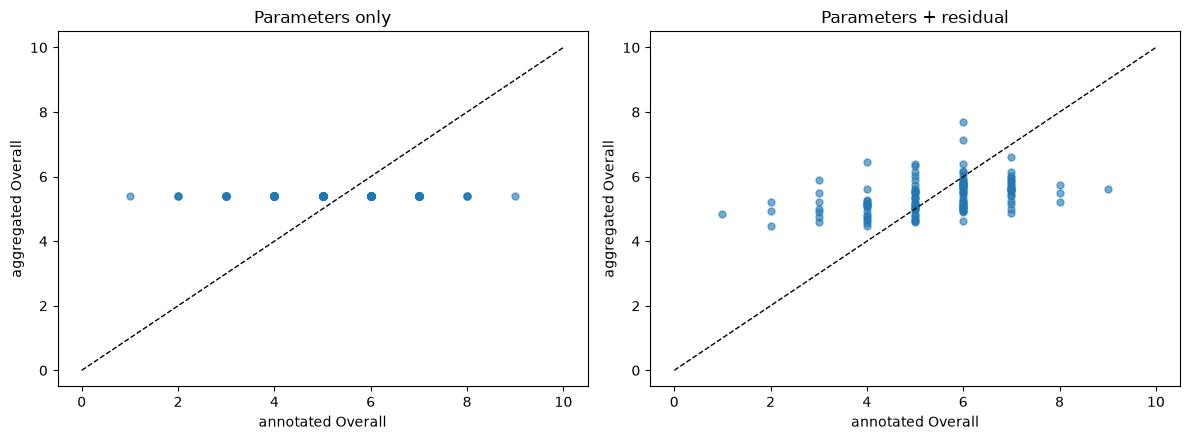

In [5]:
Xw = np.column_stack([X, residual])
with_res = LinearAggregation().fit(Xw, y)
pure = LinearAggregation().fit(X, y)
df["agg_with"] = np.clip(with_res.predict(Xw), 0, 10)
df["agg_pure"] = np.clip(pure.predict(X), 0, 10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title in [
    (axes[0], "agg_pure", "Parameters only"),
    (axes[1], "agg_with", "Parameters + residual"),
]:
    ax.scatter(df["Overall"], df[col], alpha=0.6, s=25)
    ax.plot([0, 10], [0, 10], "k--", lw=1)
    ax.set_title(title)
    ax.set_xlabel("annotated Overall")
    ax.set_ylabel("aggregated Overall")
plt.tight_layout()
plt.show()

## Decision (ADR-0001 fallback clause)

If `winner` is **with_residual**, the aggregation keeps the image-derived
channel and ADR-0001's hybrid stands. If it is **without_residual**, the
residual is dropped and the residual variance is treated as irreducible
clinician subjectivity. This notebook is rerun with the final paper model
(resnet18, GPU) to lock the decision for the manuscript.